# Generere en graf til graf-dagen
Her er det vi trenger for å kunne re-genererer grafen til graf-dagen

## Mål og strategi

*Målet* er å kunne gi en innføring i graf-teori og dens anvendelser uten å måtte gjøre for mange forberedelser.  
En viktig del er å bli kjent med bruken av *Grapgh Data Science Library* i **Neo4j**.

*Strategien* er å bygge et (stort) datasett som representerer en graf.  Vi lager den som en *tilfeldig graf* (*random graph*).  Det betyr at sannsynligheten for at en kant er med i grafen er lik for alle kanter [Erdõs-Rényi](erdos59random.pdf).  Å generere en tilfeldig graf med N noder er i utgangspunktet O(N^2).  Mange naturlig forekommende grafer har denne egenskapen; hvilken sannsynlighet vi skal bruke må eksperimenter vise.

I settet skal det finnes strukturer som er av interesse; en typisk ting å lete etter er en klikk (se nedenfor).  For å være sikker på at det vi skal lete etter faktisk finnes, genererer vi (for eksempel) klikker og legger dem inn.  Vi har en rekke egenskaper vi ønsker å demonstrere så vi legger inn mange greier.  Mer nedenfor.

Til slutt eksporerer vi den ferdige grafen i et format Neo4J kan lese.  Første del av "kurset" blir derfor å lese inn grafen, og legge den inn Neo4j.  

Det hele er altså å legge til rette for å lære Neo4J gjennom eksempler vi har konstruert for anledningen.

## Eksempel
For å illustrere skal vi bruke et datasett, inspirert av ingen ringere enn [Donal Knuth](https://en.wikipedia.org/wiki/Donald_Knuth): Personene i [Victor Hugos](https://en.wikipedia.org/wiki/Victor_Hugo) roman [Les Misérables](https://en.wikipedia.org/wiki/Les_Mis%C3%A9rables) og deres relasjoner.  Formålet er bare å visualisere noe mindre, slik at vi kan "se" hva som skal skje.

Orginaldata er [her](https://github.com/MADStudioNU/lesmiserables-character-network).

In [12]:
import networkx as nx
import matplotlib.pyplot as plt

In [13]:
with open("lesmiserables-character-network/parsed_data/jean-complete-node.csv", "r") as fd:
    noder_rå = fd.readlines()
#
# Bort med første linje
noder_rå = noder_rå[1:]

# Formatet er 
# "TH","Thénardier","Thénardier, innkeeper in Montfermeil, aka Jondrette"\n
# Hent ut det vi trenger, og lag noder

G = nx.Graph()
for n in noder_rå:
    _s = n.split('"')
    G.add_node(_s[1], Navn=_s[3], Rolle=_s[5])
#
print(f"Antall noder i grafen: {G.number_of_nodes()}")

# Kantene
with open("lesmiserables-character-network/parsed_data/jean-complete-edge.csv", "r") as fd:
    kanter_rå = fd.readlines()
#
# Bort med første
kanter_rå = kanter_rå[1:]
print(f"Antall kanter: {len(kanter_rå)}")
#Formatet er 
# "MY","NP","Undirected","1","1.1.1" 
# hvor 1.1.1 er kapittelet hvor forbindelsen opptrer
for k in kanter_rå:
    _s = k.split(",")
    _ = G.add_edge(_s[0][1:3], _s[1][1:3])

Antall noder i grafen: 181
Antall kanter: 1589


Vise frem hele grafen

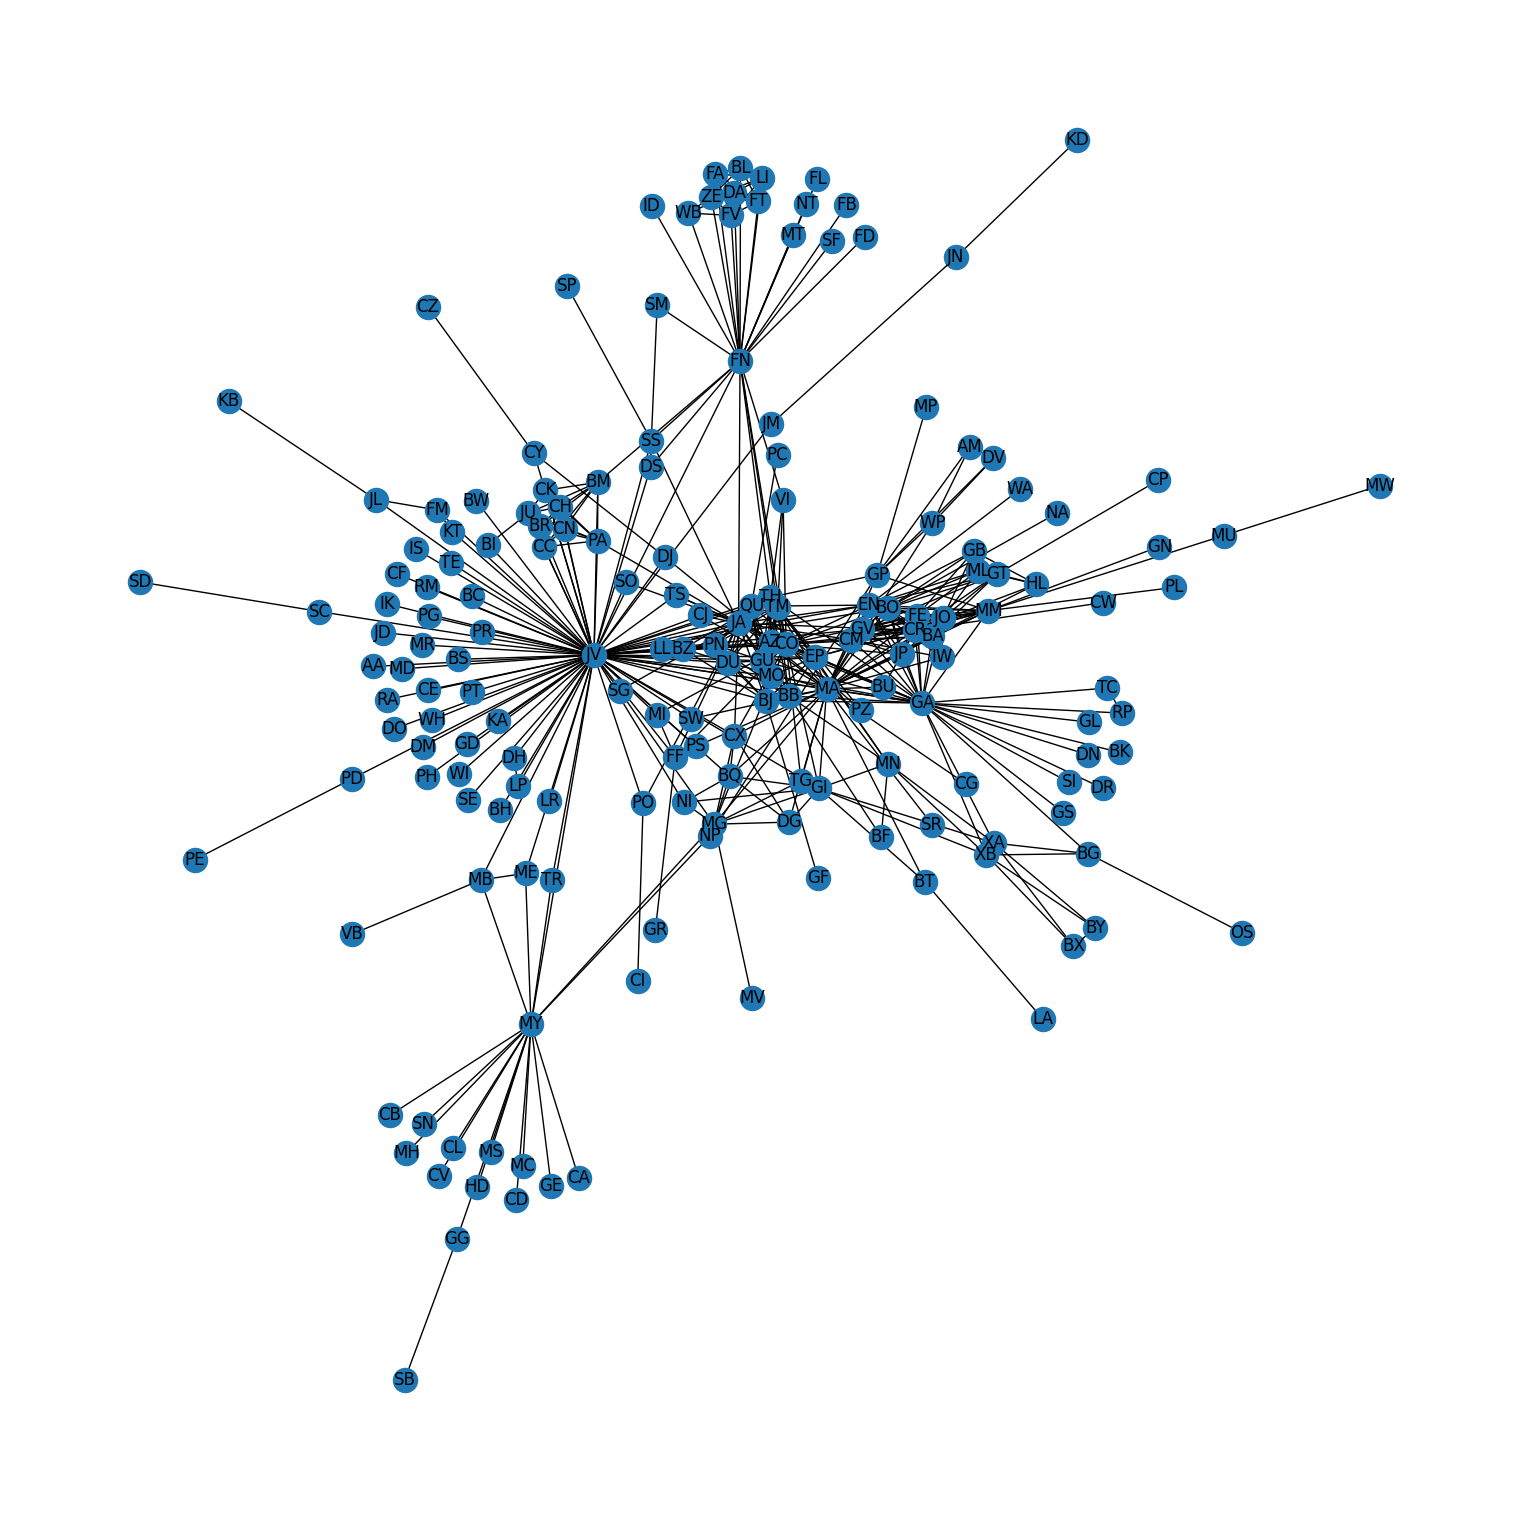

In [14]:

plt.figure(figsize=(15,15))
pos = nx.spring_layout(G)  # Be nodene spre seg utover så godt de kan
nx.draw(G, pos, with_labels=True)


## Nomenklatur

### En klikk
En **klikk** er et sett med noder hvor alle har en forbindelse til alle andre.  En graf kan åpenbart ha ingen, én, eller mange klikker.  Vanligvis regner vi ikke med klikker som bar mindre enn tre medlemmer (fordi enhver kant mellom to noder da blir en klikk).  En (sub)graf som er en klikk sies å være **komplett**.  Naturligvis, alle deler av en komplett klikk er også en klikk; det interessante er å finne den maksimale klikken.

Om vi ser bort fra at at det å finne klikker i grafer lett kan bli NP-komplett ([Karp](https://en.wikipedia.org/wiki/Karp%27s_21_NP-complete_problems)) så er jo klikker steder i grafen hvor det er ekstra mye "kommunikasjon".  Hos oss lar vi klikker representere en "gjeng" hvor alle kjenner hver andre og samarbeider.

Største klikk: ['CR', 'MA', 'GA', 'EN', 'CM', 'GV', 'BO', 'FE', 'JO', 'BA', 'MM']


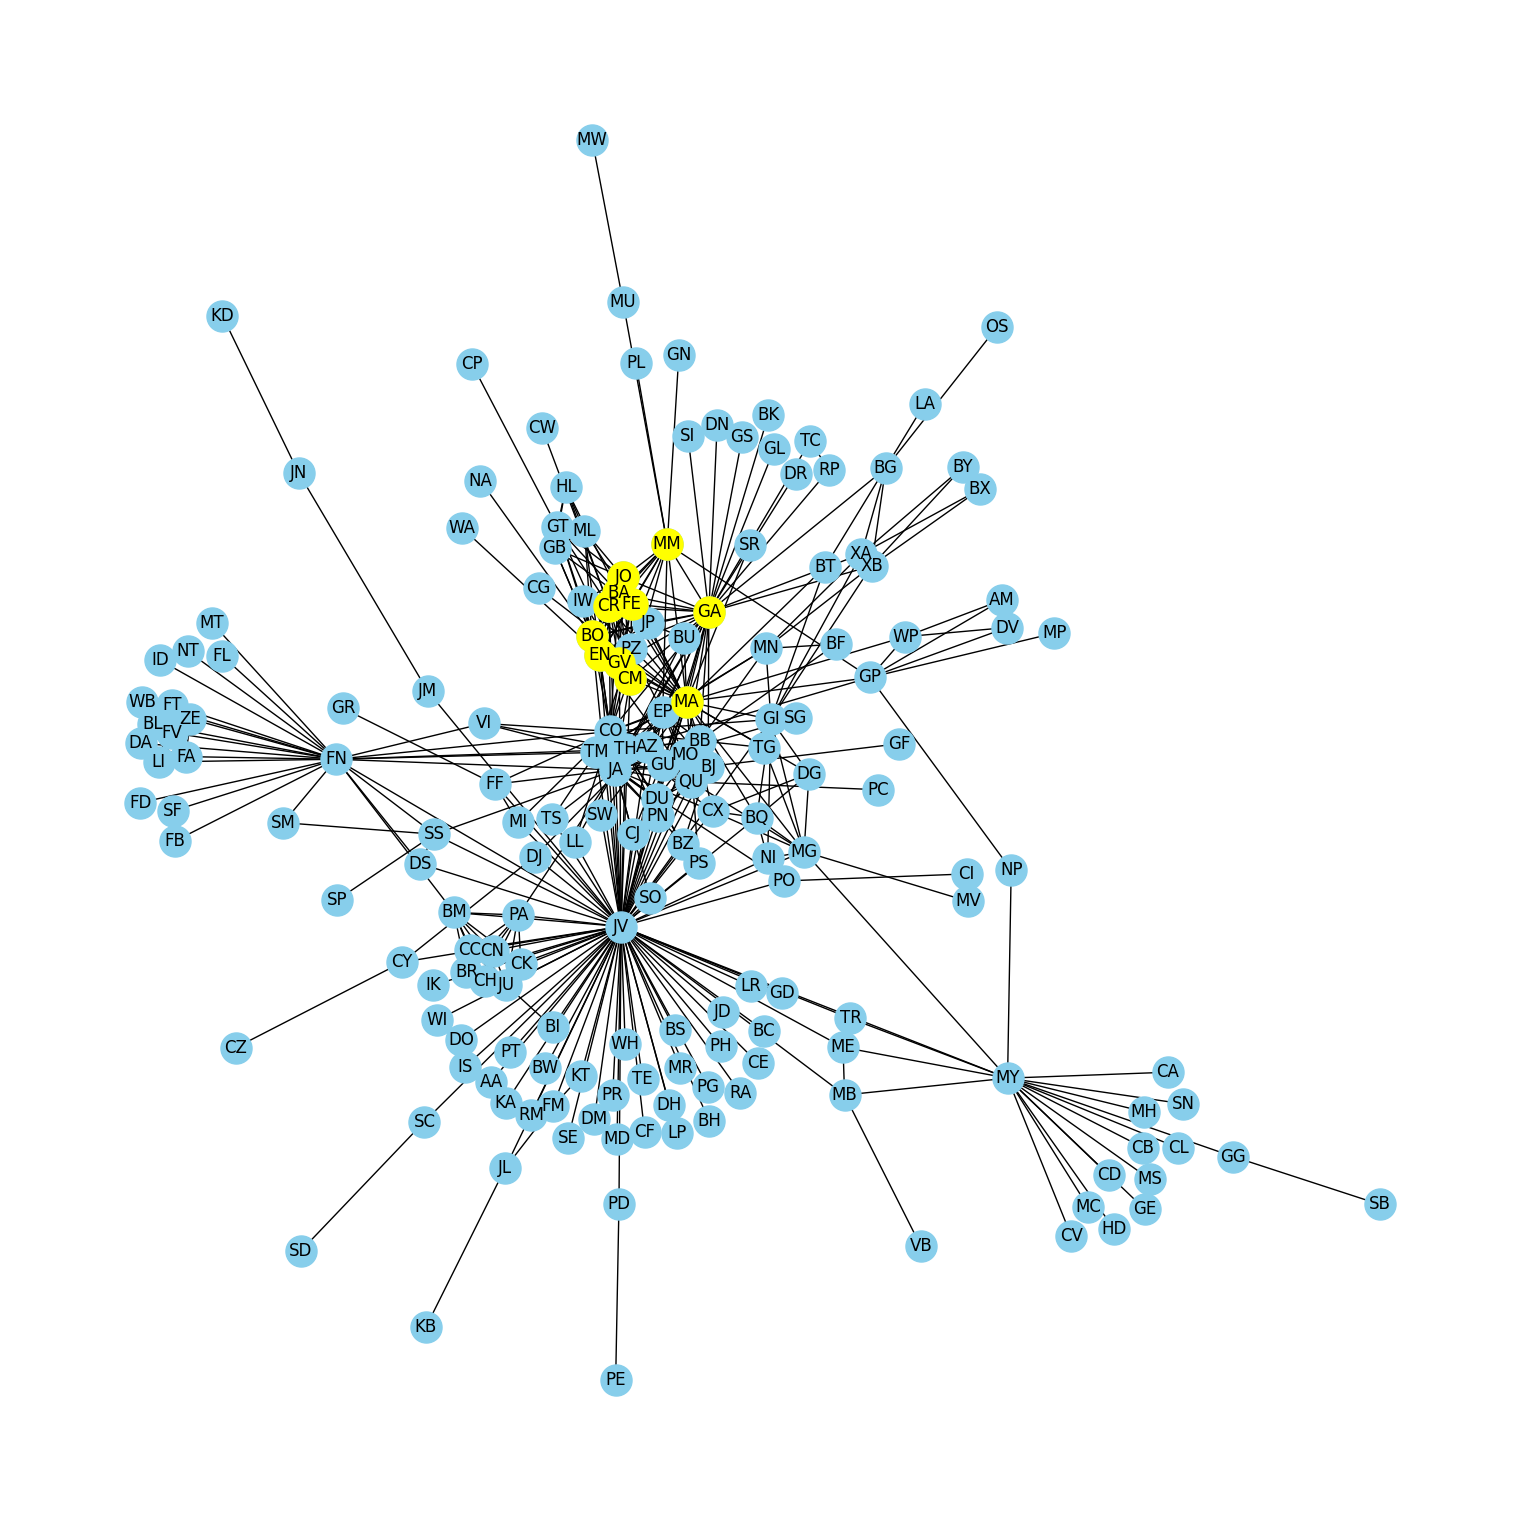

In [15]:
# Finn den største klikken i grafen
klikker = list(nx.find_cliques(G))
# Finn den lengste listen i listen av noder
klikk = max(klikker, key=len)

# Hvem er med
print("Største klikk:", klikk)

# Få se
plt.figure(figsize=(15, 15))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='skyblue', font_size=12, node_size=500)

# Gi klikken en annen farge
nx.draw_networkx_nodes(G, pos, nodelist=klikk, node_color='yellow', node_size=500)
plt.show()

Det er mulig å hente ut klikken

	 CR {'Navn': 'Courfeyrac', 'Rolle': 'Courfeyrac, member, Friends of the ABC'}
	 CM {'Navn': 'Combeferre', 'Rolle': 'Combeferre, member, Friends of the ABC'}
	 GV {'Navn': 'Government troops', 'Rolle': 'Government troops'}
	 EN {'Navn': 'Enjolras', 'Rolle': 'Enjolras, chief of Friends of the ABC'}
	 MA {'Navn': 'Marius', 'Rolle': 'Marius'}
	 GA {'Navn': 'Gavroche', 'Rolle': 'Gavroche, son of the Thénardiers'}
	 BO {'Navn': 'Bossuet', 'Rolle': 'Bossuet (Lesgle), member, Friends of the ABC'}
	 FE {'Navn': 'Feuilly', 'Rolle': 'Feuilly, member, Friends of the ABC'}
	 BA {'Navn': 'Bahorel', 'Rolle': 'Bahorel, member, Friends of the ABC'}
	 MM {'Navn': 'M. Mabeuf', 'Rolle': 'M. Mabeuf, warden of St. Sulpice, bibliophile'}
	 JO {'Navn': 'Joly', 'Rolle': 'Joly, member Friends of the ABC'}


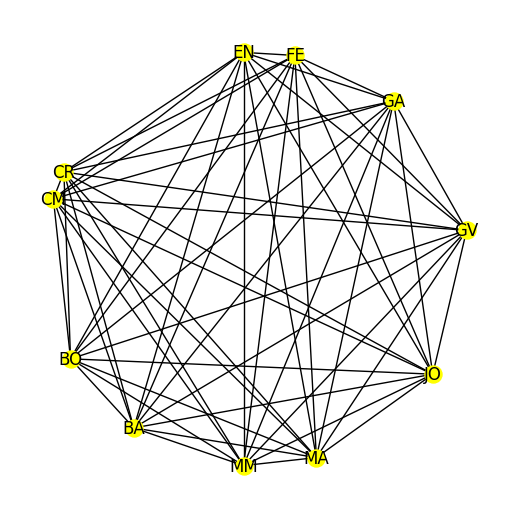

In [16]:

sg = G.subgraph(klikk)
for n in sg:
    print("\t", n, sg.nodes[n])
# 
plt.figure(figsize=(5, 5))
pos = nx.circular_layout(G)
nx.draw(sg, pos, with_labels=True, node_color='yellow', node_size=150)

At den største klikken er såpass liten er nok fordi dette er en roman og ingen "kjenner" hverandre utover det som er relevant for handlingen; hvem sa at litteraturen er eneste stedet mennesket har ekte frihet :-)

Kilkker er "sterke" strukturer, som ikke oppstår så lett "uten grunn".  Vi skal returnere til klikker senere, etter at vi har sett på hva en "tilfeldig" graf er.

###  Bronode
En **bronode** (eng: *betweenness centrality*) er en node som knytter andre (sett av) noder sammen.  Det vil si en node som mye vil passere gjennom når det sprer seg utover i grafen.  

Teknisk betyr det være på *korteste sti* mellom mange sett av noder.

### Populær node
En node blir **populær** (eng: *degree centrality*) når den har mange forbindelser (relativt til resten av grafen).

### Sentral node
En **bronode** ligger på korteste sti for mange (par av) noder.  En **sentral** node (eng: *closeness centrality*) har lav sum av korteste sti 
til andre noder.  Det vil si at informasjon fra andre steder i grafen når denne noden raskt.
Det er en klar sammenheng mellom **bronoder** og **sentrale noder**.

In [18]:
# Beregne de tre viktigste typene sentralitet

populæritet = nx.degree_centrality(G)
broer = nx.betweenness_centrality(G)
sentrale = nx.closeness_centrality(G)

top_populære_noder = sorted(populæritet, key=populæritet.get, reverse=True)[:5]
top_bronoder = sorted(broer, key=broer.get, reverse=True)[:5]
top_sentrale = sorted(sentrale, key=sentrale.get, reverse=True)[:5]

print("5 mest populære:")
for n in top_populære_noder:
    print("\t", n, G.nodes[n])
#
print("5 viktigste bronoder")
for n in top_bronoder:
    print("\t", n, G.nodes[n])
#
print("5 mest sentrale noder:")
for n in top_sentrale:
    print("\t", n, G.nodes[n])
#   


5 mest populære:
	 JV {'Navn': 'Jean Valjean', 'Rolle': 'Jean Valjean'}
	 MA {'Navn': 'Marius', 'Rolle': 'Marius'}
	 GA {'Navn': 'Gavroche', 'Rolle': 'Gavroche, son of the Thénardiers'}
	 JA {'Navn': 'Javert', 'Rolle': 'Javert, police officer'}
	 FN {'Navn': 'Fantine', 'Rolle': 'Fantine, mistress of Tholomyès'}
5 viktigste bronoder
	 JV {'Navn': 'Jean Valjean', 'Rolle': 'Jean Valjean'}
	 FN {'Navn': 'Fantine', 'Rolle': 'Fantine, mistress of Tholomyès'}
	 GA {'Navn': 'Gavroche', 'Rolle': 'Gavroche, son of the Thénardiers'}
	 MY {'Navn': 'Bishop Myriel', 'Rolle': 'M. Myriel, Bishop of Digne'}
	 MA {'Navn': 'Marius', 'Rolle': 'Marius'}
5 mest sentrale noder:
	 JV {'Navn': 'Jean Valjean', 'Rolle': 'Jean Valjean'}
	 JA {'Navn': 'Javert', 'Rolle': 'Javert, police officer'}
	 MA {'Navn': 'Marius', 'Rolle': 'Marius'}
	 CO {'Navn': 'Cosette', 'Rolle': 'Cosette, daughter of Fantine'}
	 GA {'Navn': 'Gavroche', 'Rolle': 'Gavroche, son of the Thénardiers'}


Tegne bronoder som et tre

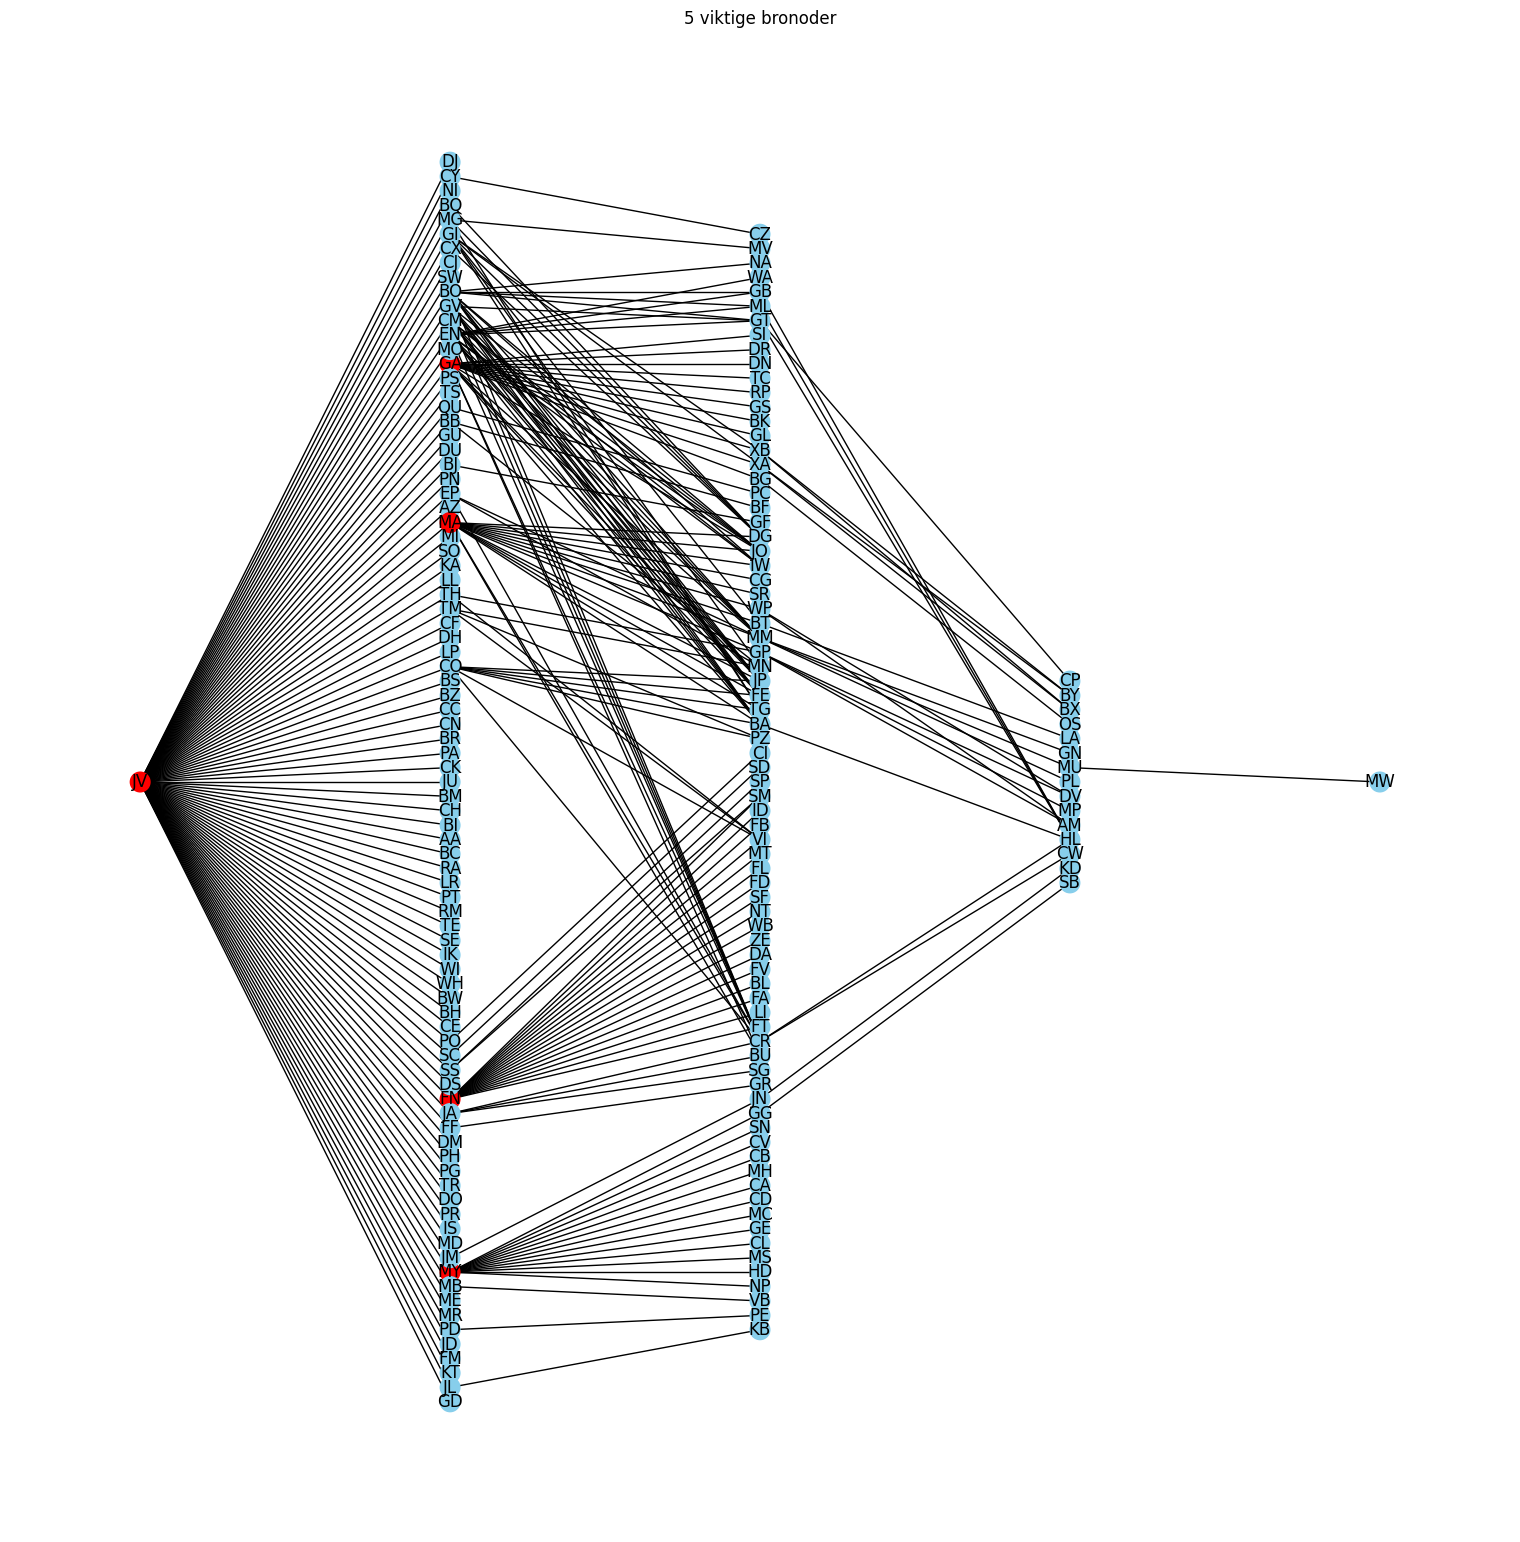

In [19]:

plt.figure(figsize=(15, 15))
node_farge = []
for n in G.nodes():
    if n in top_bronoder:
        node_farge += ["red"]
    else:
        node_farge += ["skyblue"]
    #
# Eller om du vil lese fra høyre mot venstre: ['red' if node in top_bronoder else 'skyblue' for node in G.nodes()]
pos = nx.bfs_layout(G, start="JV")  # Layout og startnode
nx.draw(G, pos, with_labels=True, node_color=node_farge, node_size=200)
plt.title("5 viktige bronoder")
plt.show()

### Viktige noder ("page rank")
Den rekursive definisjonen sier at en node blir **viktig** dersom de den har forbindelse til er viktige.  Vi starter med å telle antall kanter 
inn til en node (som gir en første indikasjon på hvor viktig noden er).  Så øker vi viktigheten dersom naboene er viktige.  Kalles populært *page rank*, altså "Google".

For matematisk bakgrunn se [Eigenvektor centrality](https://en.wikipedia.org/wiki/Eigenvector_centrality) (finn frem de gamle lærebøkene i lineær algebra :-) ).


5 mest populære:
	 JV {'Navn': 'Jean Valjean', 'Rolle': 'Jean Valjean'}
	 MA {'Navn': 'Marius', 'Rolle': 'Marius'}
	 GA {'Navn': 'Gavroche', 'Rolle': 'Gavroche, son of the Thénardiers'}
	 JA {'Navn': 'Javert', 'Rolle': 'Javert, police officer'}
	 CO {'Navn': 'Cosette', 'Rolle': 'Cosette, daughter of Fantine'}


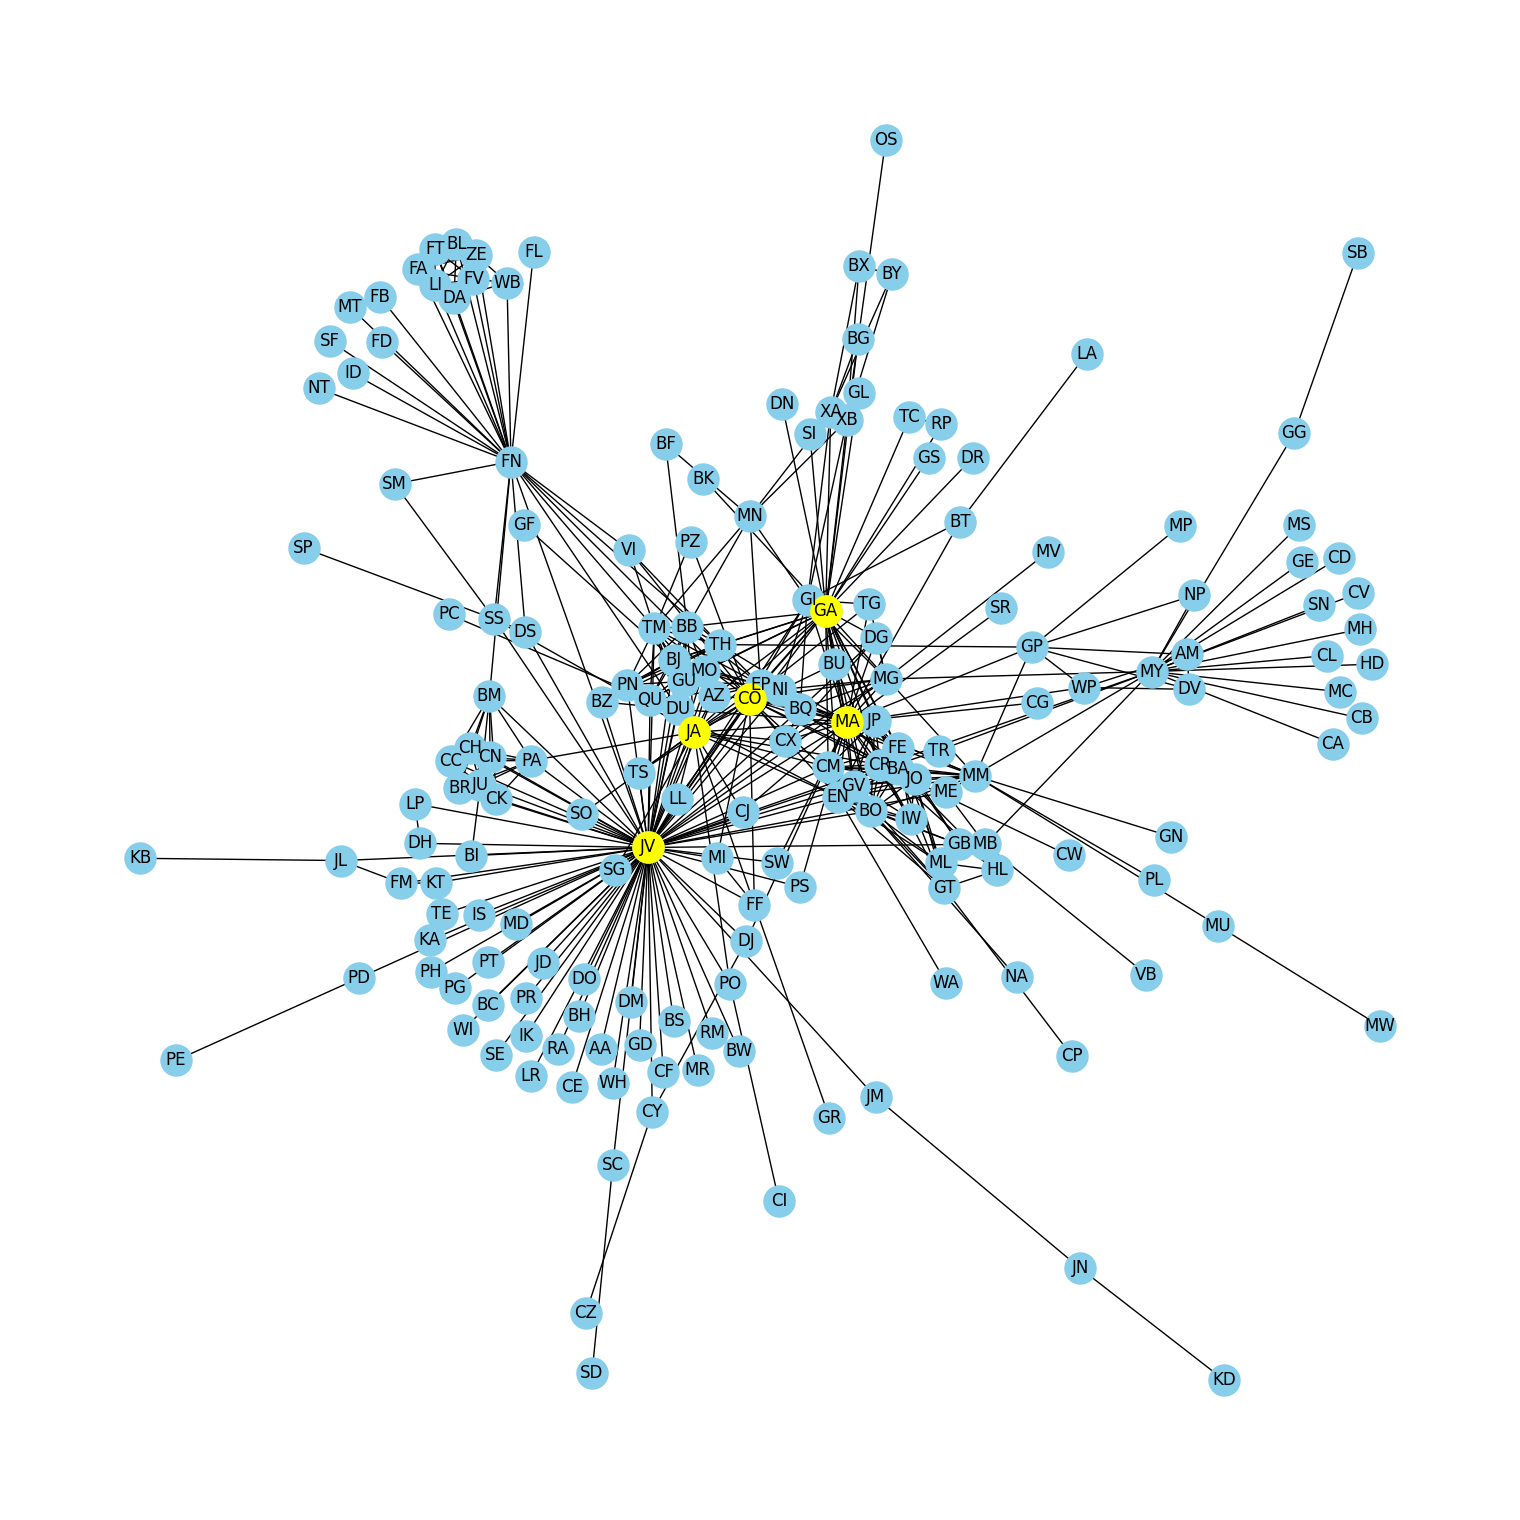

In [20]:
# Beregne de viktigste nodene

page_rank = nx.eigenvector_centrality(G)

viktigste_noder = sorted(page_rank, key=page_rank.get, reverse=True)[:5]

print("5 mest populære:")
for n in viktigste_noder:
    print("\t", n, G.nodes[n])
#   

# Få se
plt.figure(figsize=(15, 15))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='skyblue', font_size=12, node_size=500)

# Gi de viktige en annen farge
nx.draw_networkx_nodes(G, pos, nodelist=viktigste_noder, node_color='yellow', node_size=500)
plt.show()

### Tetthet
Hvor tett en graf er avhenger av forholdet mellom antall kanter (mellom noder) mot potensielt (totalt) antall kanter.  Når vi genererer en tilfeldig graf (se nedenfor) vil tettheten være en funksjon av sannsynligheten.


In [14]:
# Tettheten
tetthet = nx.density(G)
print(f"Grafens tetthet: {tetthet:.4f}")

Grafens tetthet: 0.0300


### Diameter
Den lengste korteste sti; gir et mål på maksimal avstand mellom deltagerne (nodene).  I en tilfeldig graf vil diameteren være en funksjon av antall noder.

In [21]:
# Grafens diameter
# Husk: Diameter er bare gyldig i grafer som ikke er delt.
if nx.is_connected(G):
    diameter = nx.diameter(G)
    print(f"Diameter: {diameter}")
else:
    # Dersom grafen er delt, finn største subgraf, og se på den
    største_sg = max(nx.connected_components(G), key=len)
    subgraf = G.subgraph(største_sg)
    diameter = nx.diameter(subgraf)
    print(f"Diameter (største del): {diameter}")

Diameter: 7


Dette er en roman, og med en tetthet på bare 0.03 (3%) kan det synes som om de fleste personene ikke deltar direkte i handlingen, men kanskje som "staffasje" i scener.

En diameter på 7, med en tetthet på bare 0.03, indikerer en graf med et par "tentakler" som strekker seg utover.  I handlingen kan det tyde på et par "digresjoner" hvor handlingen inkluderer person er som ellers ikke er med.

### Gjeng
Vi kan definere en **gjeng** som et sett av noder som "henger sammen" men som henger løst sammen med resten.  Vi kan bruke [Girvan-Newman](https://en.wikipedia.org/wiki/Girvan%E2%80%93Newman_algorithm) til å finne slike gjenger.  

Konseptet med en bronode er at mange korteste-sti passerer gjennom noden (som gjør den sentral sett i lys av informasjonsspredning).  Vi kan flytte fokus fra nodene til kantene, og sette vekt på kantene basert på hvor mange korteste-sti som går gjennom dem.  Ved å fjerne slike kanter fragmenteres grafen, og gjengene står igjen.

De som først separeres ut er de som har bronoder som har få (meen viktige) forbindelser til resten.

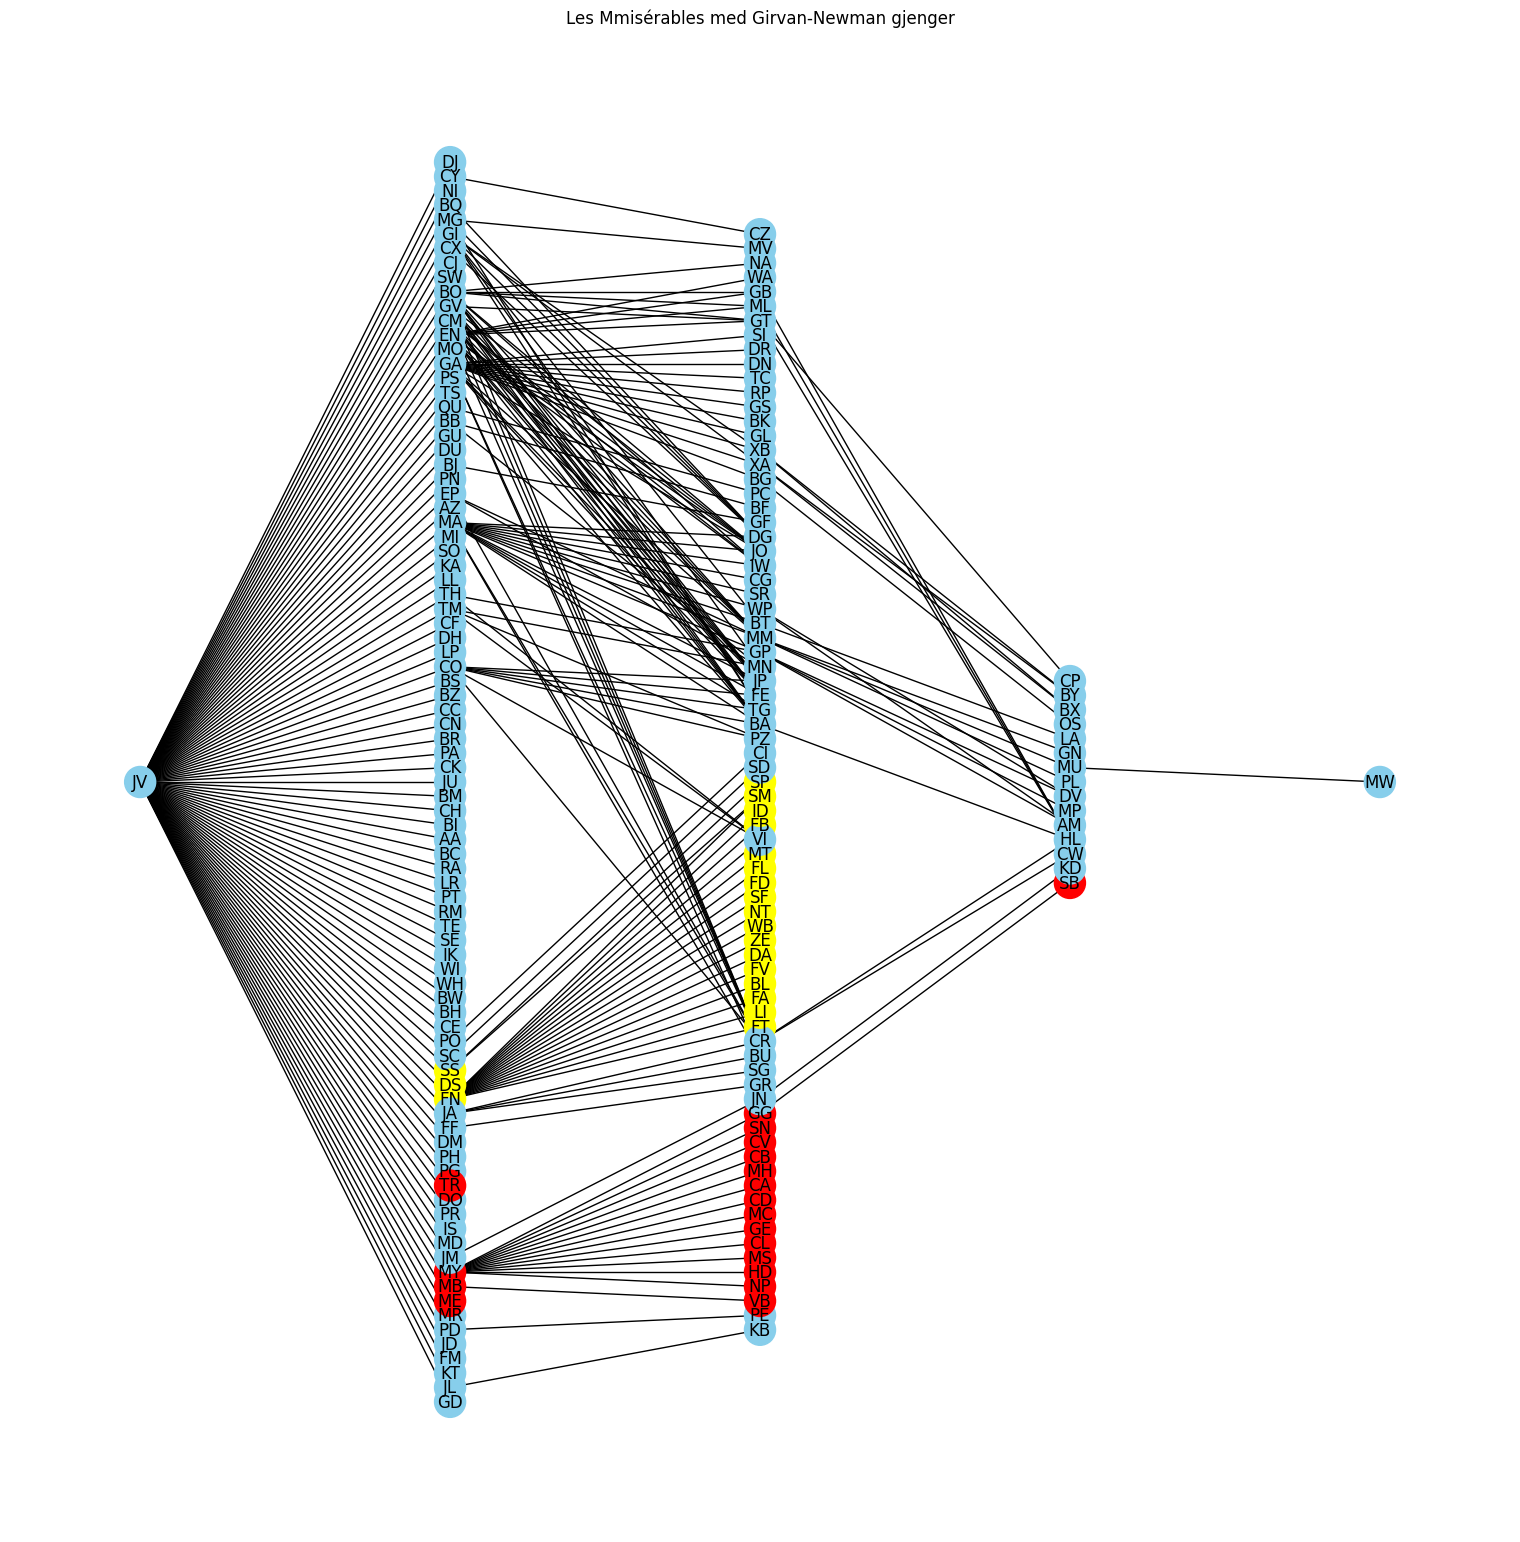

In [22]:
from networkx.algorithms.community import girvan_newman
gener = girvan_newman(G)
# Returnerer en generator
gjenger = []
for g in gener:
    gjenger += g
#
# Ta med de fire første (som er "resten" pluss tre)
gjenger = gjenger[:5]

node_farge= []
for n in G.nodes():
    if n in gjenger[3]:
        node_farge += ["yellow"]
    elif n in gjenger[2]:
        node_farge += ["skyblue"]
    elif n in gjenger[1]:
        node_farge += ["red"]
    else:
        node_farge += ["green"] # Skal ikke bli noen
    #
#

# Vis frem
pos = nx.bfs_layout(G, start="JV")
plt.figure(figsize=(15, 15))

nx.draw(G, pos, with_labels=True, node_color=node_farge, font_size=12, node_size=500)
plt.title("Les Mmisérables med Girvan-Newman gjenger")
plt.show()

## Fremgangsmåte

Vi bruker [NetworkX](https://networkx.org/documentation/stable/index.html) til å genererer opp grafen vår.  
Fordi det er utfordringer med formatene, vi vil eksportere til JSON og bruke Python til å legge noder og kanter inn i Neo4j.

# Økonomisk kriminalitet
Formålet her er ikke å undervise i økonomisk kriminalitet.  Eksemplene vi har valgt er derfor syntetiske.

## Datamodell

Vi velger en (svært) enkel datamodell som "til en viss grad" reflekterer økonomisk kriminalitet.

### Noder
Følgende er noder:
- Peroner: Har relasjoner til andre personer, eier konti, og gjennomfører transkasjoner;
- Konto som tilhører en person, og
- Transaksjoner (relasjonene til konto og person gir kontekst).

### Relasjoner (kanter)
- **kjenner** er relasjonen mellom to personer.  Det er åpenbart en (veldig) forenkling av virkeliheten, med godt nok.
- **Kontoeier** er relasjonen fra en konto til en person
- Noden Transaksjon har ENTEN tre kanten (til to konti, én merket **fra** og én merket **til**) og én til en person (som utførte transaksjonen) ELLER to kanter hvor den ene går til personen og den andre til en konto.  I dette tilfellet er transkasjonen merket med "type" som er enten "uttak" eller "innskudd".  I alle tilfeller har transaksjonen et beløp.

Datamodellen vil begrense hva vi kan representere.  Det vil si at med denne enkle modellen er begrenset til å studere "enkle" representasjoner av strukturelle egenskaper.  Mer om det senere.

In [23]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import uuid
import scipy
from datetime import datetime, timedelta

Norske navn fra SSB som vi legger til nodene

In [24]:
# Norske navn
ordliste = []
with open("ordliste.txt", "r") as fd:
    for linje in fd:
        ordliste.append(linje.split("|")[1])
    #
#

Slik ser en person ut, og alle personer har konto (i det minste for tiden).  Alle noder har en UUID4 som identifikator for å sikre oss mot kollisjoner på selve identifikatoren; gjør livet lettere når ting skal settes sammen.

In [25]:
def lag_person_konto(G, 
                     navn=random.choice(ordliste)):
    id = str(uuid.uuid4())
    G.add_node(id, person=True)
    G.nodes[id]["navn"] = navn
    kto = str(uuid.uuid4())
    G.add_node(kto, konto=True)
    G.add_edge(id, kto, kontoeier=True)
    return (id, kto)
#fed

### "Money Mule"
Alle medlemmene i en klikk, unntatt én som vi kaller M, tar ut penger.  Deretter (i tid) setter Bakmannen, som M har relasjon til, et beløp som er noe mindre enn summen av det som er tatt ut.  Det endelige innskuddet skjer naturligvis en stund etter at alle uttakene er gjort.
Uttakene spres utover i tid (fra nå og fremover) og beløpet varierer opp til en grense.  M tar ikke ut penger (han får dem i kontanter).

Vi lager en klikk (og derfor en graf) og setter opp alle realsjonene.

Den skyldige er: Kristen: 211a6652-242e-42a7-b56b-b614ade87893


<Figure size 500x500 with 0 Axes>

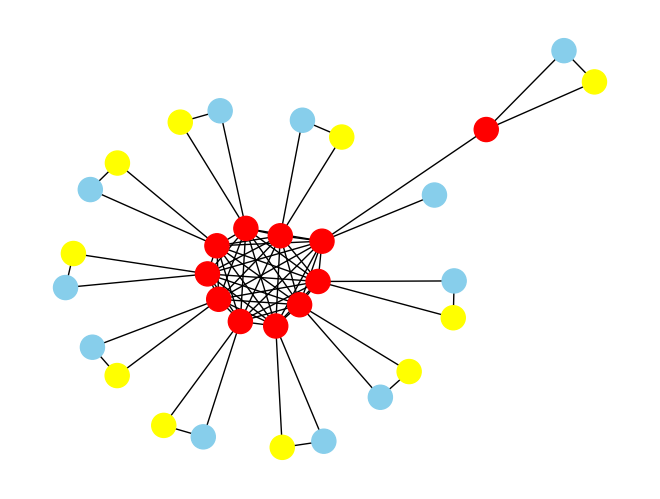

<Figure size 500x500 with 0 Axes>

In [26]:

def lag_money_mule(antall_personer, total_beløp):

    # Uttakene skjer innen dette vinduet
    vindu_uttak = 8 
    #ANtall dager senere innskuddet skjer
    når_skjer_innskuddet = 2
    
    # Lag en klikk.
    uid = []
    for i in range(antall_personer):
        uid.append(str(uuid.uuid4()))
    #
    G = nx.complete_graph(uid)
    # Sett typen til personer
    nx.set_node_attributes(G, True, "person") # OBS rekkefølgen på parametrene!
    nx.set_edge_attributes(G, True, "kjenner")

    # Legg til et navn
    for id in G.nodes:
        G.nodes[id]["navn"] = random.choice(ordliste)
    #
    # Finn den som skal være forbryteren
    M = random.choice(list(G.nodes()))
    print(f"Den skyldige er: {G.nodes[M]["navn"]}: {M}")

    # Lage konti (med random id) til alle deltagere
    noder = list(G.nodes())
    for n in noder:
        kto = f"konto-{n}"
        G.add_node(kto, konto=True)
        G.add_edge(n, kto, kontoeier=True)
    #
    # Legg til en bakmann med konto
    bakmann, bak_kto = lag_person_konto(G, "Bakmann")
    # M kjenner bakmannen
    G.add_edge(M, bakmann, kjenner=True)

    # Alle skal ta ut penger (kontanter)
    folk = []
    for n,p in list(G.nodes(data="person")):
        if p:
            folk.append(n)
        #
    #    
    
    # Disse to skal ikke ta ut penger
    folk.remove(bakmann)
    folk.remove(M)

    bak_beløp = 0 # Totalt beløp tatt ut
    for person in folk:
        id = str(uuid.uuid4())
        beløp = round(total_beløp * random.random(), 2)
        G.add_node(id, 
                   transaksjon = True,
                   uttak = True,
                   beløp=beløp,
                   tidspunkt = datetime.now() + timedelta(hours=vindu_uttak * random.random()))
        bak_beløp += beløp
        G.add_edge(id, person, transaksjon=True)
        # Finn personens konto ved å se på kantene ut fra personen
        for u, v, kto in G.edges([person], data=True):
            if "kontoeier" in kto:
                G.add_edge(id, v, transaksjon=True)
                break
            #
        #
    # for person

    # Bakmannen setter inn pengene, minus ca 25% neste dag
    id = str(uuid.uuid4())
    G.add_node(id,
               transaksjon = True,
               innskudd = True,
               beløp = bak_beløp - round(bak_beløp * random.random() * 0.25, 2), 
               tidspunkt = datetime.now() + timedelta(days=når_skjer_innskuddet))
    G.add_edge(id, bakmann, transaksjon=True)
    G.add_edge(id, bak_kto, transaksjon=True)

    return G
#fed

#
#
G = lag_money_mule(10, 1000)
#
#


# Fjern identifikatorene
#G = nx.convert_node_labels_to_integers(G)
# Tegne
node_farge = []
for n,d in G.nodes(data=True):
    if "person" in d:
        node_farge += ["red"]
    elif "konto" in d:
        node_farge += ["skyblue"]
    elif "transaksjon" in d:
        node_farge += ["yellow"]
    else:
        node_farge += ["green"]
    #
#
pos = nx.spring_layout(G)  # Be nodene spre seg utover så godt de kan
nx.draw(G, with_labels=False, node_color=node_farge, node_size=300)
plt.figure(figsize=(5,5))



### Bakmann
En som knytter sammen flere klikker

<Figure size 500x500 with 0 Axes>

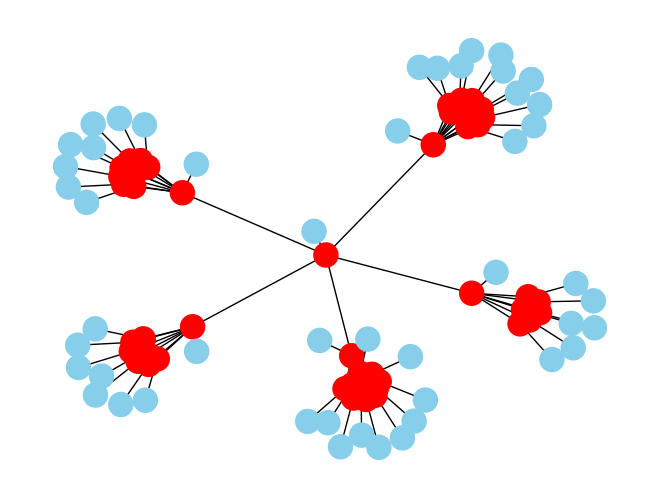

<Figure size 500x500 with 0 Axes>

In [27]:
def bakmann_klikker(antall_klikker, antall_personer):
    assert(antall_klikker > 0)
    assert(antall_personer > 0)
    
    klikker = []
    for k in range(antall_klikker):
        # Lag en klikk med et varierende antall personer rundt antallte
        antall = int(antall_personer + antall_personer/4*random.uniform(-1, 1))
        folk = []
        for f in range(antall):
            folk.append(str(uuid.uuid4()))
        #
        G = nx.complete_graph(folk)
        # Sett typen til personer
        nx.set_node_attributes(G, True, "person") # OBS rekkefølgen på parametrene!
        nx.set_edge_attributes(G, True, "kjenner")
        # Legg til et navn til alle
        for id in G.nodes():
            G.nodes[id]["navn"] = random.choice(ordliste)
        #
        
        # Lage konti (med random id) til alle deltagere
        noder = list(G.nodes())
        for n in noder:
            kto = f"konto-{n}"
            G.add_node(kto, konto=True)
            G.add_edge(n, kto, kontoeier=True)
        #
        klikker.append(G)
    #
    
    komplett = nx.Graph()
    # Legg til en bakmann med konto
    bakmann, bak_kto = lag_person_konto(komplett, "Bakmann")
    
    for klikk in range(len(klikker)):
        # velg en node i klikken
        kopi = list(klikker[klikk].nodes(data=True))        
        random.shuffle(kopi)
        # det skal være minst én person
        for n, d in kopi:
            if "person" in d:
                kontakt = n
                break
            #
        #
        # IDer i klikken som legges til får ID av typen 5-uuid4.
        komplett = nx.union(komplett, klikker[klikk], ("", f"{klikk}-"))
        komplett.add_edge(bakmann, f"{klikk}-{kontakt}", kjenner=True)
    #

    return(komplett)
#fed

G = bakmann_klikker(5, 10)
# Tegne
node_farge = []
for n,d in G.nodes(data=True):
    if "person" in d:
        node_farge += ["red"]
    elif "konto" in d:
        node_farge += ["skyblue"]
    elif "transaksjon" in d:
        node_farge += ["yellow"]
    else:
        node_farge += ["green"]
    #
#

pos = nx.spring_layout(G)  # Be nodene spre seg utover så godt de kan
nx.draw(G, with_labels=False, node_color=node_farge, node_size=300)
plt.figure(figsize=(5,5))


### Utbytte
Én stor transaksjon som tilsynelatende "spittes" i flere og sprer seg utover.  Det starter med ett stort innskudd av kontanter, som så spres utover flere personer.  Tiden går, samtidig som beløpet blir mindre

Dele en pengesum på et antall mennesker, mer eller mindre jevnt, innen et max og et min per person

For N personer, del beløpet opp i N-biter, pluss-minus 20%.  LEgg det som måtte være igjen til én av dem

In [28]:
def del_beløp(beløp, antall):
    penger = []
    igjen = beløp
    for p in range(antall):
        andel = beløp / antall * random.uniform(0.8, 1.2)
        if andel >= igjen:
            penger.append(round(igjen, 2))
            igjen = 0
        else:
            penger.append(round(andel, 2))
            igjen -= andel
        #
    #
    if igjen > 0:
        penger[0] += round(igjen, 2)
    #
    return penger
#


In [29]:

a = del_beløp(5000, 5)
print(a)
print(sum(a))

[1191.74, 1087.17, 836.77, 950.61, 933.7]
4999.99


In [30]:
# Er beløpet mindre enn dette, da beholder du det
MINIMUM_BELØP = 5000
CUT = 15 # inntil, i prosent

def del_utbyttet(G, bakmann, beløp, klokken):
    if beløp < MINIMUM_BELØP:
        #print(f"Beløpet {beløp} deles ikke")
        return
    #
    #print(f"Klar til å trekke cut av {beløp}")
    # ditt cut
    beløp -= round(int(beløp * random.randint(1, CUT) / 100), 2)
    #print(f"Det som skal deles er: {beløp}")
    # Vi gjør jobben litt senere i dag
    tidspunkt = klokken + timedelta(days=random.random())
    # Hvor mange vi deler med avhenger av hvor stort beløpet er (logaritmisk, HEX)
    import math
    antall = round(math.log(beløp, 10))
    bøtter = del_beløp(beløp, antall)
    #print(f"Beløpet {beløp} skal deles slik: {bøtter}")
    for b in bøtter:
        # Person å sende penger til
        person, kto = lag_person_konto(G)
        G.add_edge(bakmann, person, kjenner=True)
        # Finne bakmannens konto
        naboer = G[bakmann]
        b_kto = None
        for n in naboer:
            if "konto" in G.nodes[n]:
                b_kto = n
                break
            #
        #
        assert (n is not None)
        
        # Overfør pengene til hens konto
        t_id = str(uuid.uuid4())
        G.add_node(t_id,
                   transaksjon = True,
                   øverføring = True,
                   beløp=b,
                   tidspunkt = tidspunkt + timedelta(hours=random.random()))
        G.add_edge(t_id,
                   kto,
                   transaksjon=True)
        G.add_edge(t_id, 
                   b_kto,
                   transaksjon=True)
        G.add_edge(t_id, 
                   bakmann, #bakmannen gjør jobben 
                   person=True)
        # Så for hver av disse folkene, be dem gjøre det du nettopp har gjort (rekursivt)
        del_utbyttet(G, person, b, tidspunkt)
    #rof bøtter
#fed


Vi lager en bakmann, deler opp beløpet, og kaller rekursivt til beløpet er b rukt opp

In [31]:

def lag_deling_av_utbyttet(G, beløp):
 
    bakmann, bak_kto = lag_person_konto(G, "Bakmann")
    # Hen setter inn penger
    innskuddet = str(uuid.uuid4())
    nå = datetime.now()
    G.add_node(innskuddet,
               transaksjon = True,
               innskuddet = True,
               beløp = beløp,
               tidspunkt = nå)
    G.add_edge(innskuddet, bak_kto, transaksjon=True)
    G.add_edge(innskuddet, bakmann, transaksjon=True, innskudd=True)

    del_utbyttet(G, bakmann, beløp, nå+timedelta(hours=random.random()))
    return bakmann
#

G = nx.Graph()
bakmann = lag_deling_av_utbyttet(G, 1000000)
#pos = nx.spring_layout(G)  # Be nodene spre seg utover så godt de kan
#nx.draw(G, with_labels=False, node_color=node_farge, node_size=300)
#plt.figure(figsize=(5,5))

<Figure size 500x500 with 0 Axes>

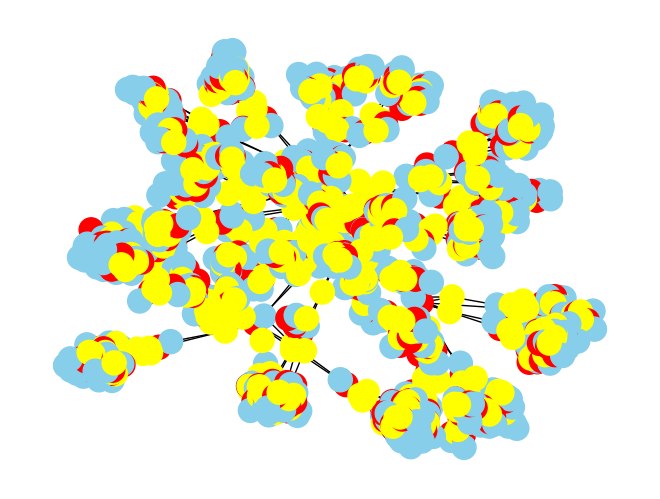

<Figure size 500x500 with 0 Axes>

In [32]:

# Tegne
node_farge = []
for n,d in G.nodes(data=True):
    if "person" in d:
        node_farge += ["red"]
    elif "konto" in d:
        node_farge += ["skyblue"]
    elif "transaksjon" in d:
        node_farge += ["yellow"]
    else:
        node_farge += ["green"] # Bør ikke være noen
    #
#

pos = nx.spring_layout(G)  # Be nodene spre seg utover så godt de kan
nx.draw(G, with_labels=False, node_color=node_farge, node_size=300)
plt.figure(figsize=(5,5))


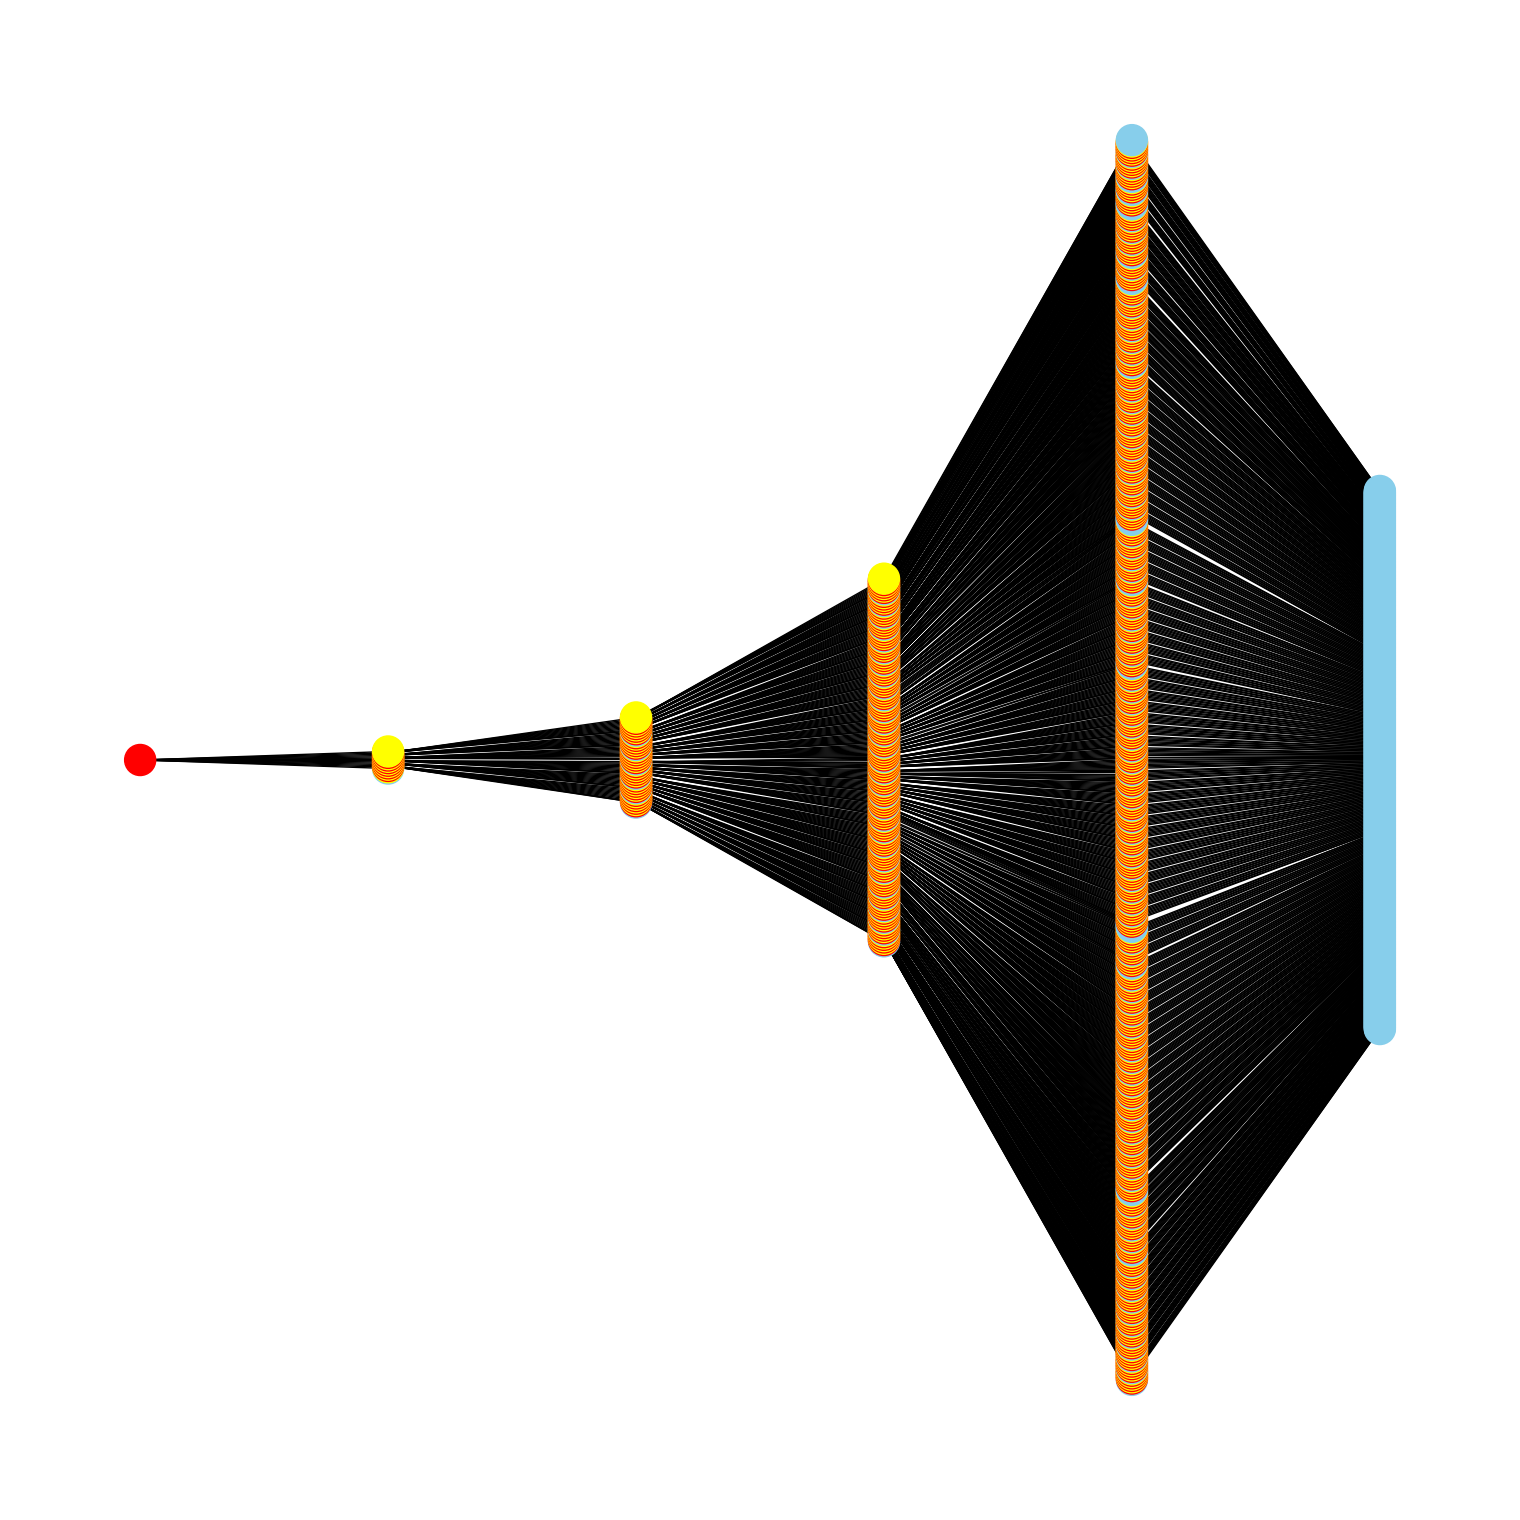

In [33]:

node_farge= []
for n,d in G.nodes(data=True):
    if "person" in d:
        node_farge += ["red"]
    elif "konto" in d:
        node_farge += ["skyblue"]
    elif "transaksjon" in d:
        node_farge += ["yellow"]
    else:
        node_farge += ["green"]
    #
#

# Vis frem
pos = nx.bfs_layout(G, start=bakmann)
plt.figure(figsize=(15, 15))

nx.draw(G, pos, with_labels=False, node_color=node_farge, font_size=12, node_size=500)
plt.show()

# Tilfeldige grafer (Random graph)

En tilfeldig graf er et gitt sett med noder hvor kantene etableres uavhengig av hverandre, med en fast sannsynlighet *p*.  Når $p=1$ er resultatet én (stor) klikk.  En slik graf heter Erdös-Renyi; en kopi av artikkelen [er her](DOC/erdos59random.pdf).  Fordi antallet noder er gitt (*n*) bestemmer sannsynligheten for at kanter opprettes grafens egenskaper; det viser seg at tilfeldige grafer laget med samme parameter er forbløffende like.

Videre, hver kant knytter enten sammen to noder som tidligere var isolerte, knytter én node til et allerede eksisterende nettverk, eller knytter to nettverk sammen.  Det interessante er at hvordan nettverk og klikker dannes skjer som brå faseoverganger.  Mer på om grafer på [Wikipedia](https://en.wikipedia.org/wiki/Network_science) og særlig om [tilfeldidge grafer](https://en.wikipedia.org/wiki/Random_graph).

Antall klikker med størrelse $k$ i en Erdõos-Rényi graf $G(n,p)$ er forventet å være
$$
	F_n(k) := {n \choose k} p^{k \choose 2} {(1-p^k)}^{n-k}
$$
Se [arXiv:2208.07492v1 16 Aug 2022](https://arxiv.org/abs/2208.07492).  Lokal kopi i DOC-katalogen.

Det vil si at om $F_n(k)$ er veldig liten, og vi finner en klikke med $k$ medlemmer, da bør vi kunne konkludere med at klikken er verdt å se nærmere på.

La oss si at en person typisk kjenner 500 mennesker (for en passende definisjon av kjenner).  I Norge bor det 5 millioner.  Det vil si at sannsynligheten for at jeg kjenner en tilfeldig person 1:10.000 eller 0.0001.

In [8]:
from scipy.special import comb

def antall_klikker(n, k, p):
    mulige = comb(n, k)
    prob = p**comb(k, 2)
    rest = (1-(p**k))**(n-k)
    total = mulige * prob * rest
    return(total)
#
ANTALL=5000000
KLIKK=5
SANN=0.0001
print(f"Forventet antall klikker med {KLIKK} medlemmer i en mengde {ANTALL} når sannsynligheten er {SANN} er {antall_klikker(ANTALL, KLIKK, SANN)}")

Forventet antall klikker med 5 medlemmer i en mengde 5000000 når sannsynligheten er 0.0001 er 2.6041614583369804e-09


I en tilfeldig graf er det derfor (svært) få klikker.  Implisitt i dette er at en tilfeldig graf i utgangspunktet ikke kan forventes å "henge sammen".  Men alle er vi med i klikker med mer enn fem medlemmer, så alarmklokkene ringer litt i bakgrunnen nå.  Kommer tilbake til det.

Problemet er å finne dem.  Å finne klikker i grafer er i utgangspunktet NP-komplett, og uten antagelser uansett svært dyrt.

In [35]:
import networkx as nx
import matplotlib.pyplot as plt
import time
import math

In [36]:
# Noen tilfeldige tall for eksempelets skyld
ANTALL = 25000
SANN = 0.01

for i in 5, 6, 7:
    print(f"Forventet antall klikker med {i} noder: {antall_klikker(ANTALL, i, SANN)}")
#rof

start = time.time()
G = nx.gnp_random_graph(ANTALL, SANN)
print(f"Å generere grafen tok {time.time()-start:.2f} sekunder")

print(f"Antall mulige kanter: {ANTALL * (ANTALL-1) / 2}")
print(f"Faktisk antall kanter: {G.number_of_edges()}")

# Finn den største klikken i grafen
start = time.time()
klikker = list(nx.find_cliques(G))
print(f"Å finne største klikken tok {time.time()-start:.2f} sekunder")
# Finn den lengste listen i listen av noder
klikk = max(klikker, key=len)

# Hvem er med
print(f"Største klikk har {len(klikk)} noder: {klikk}")


Forventet antall klikker med 5 noder: 0.8134745747879036
Forventet antall klikker med 6 noder: 3.388807885088253e-07
Forventet antall klikker med 7 noder: 1.2099980910812184e-15
Å generere grafen tok 25.12 sekunder
Antall mulige kanter: 312487500.0
Faktisk antall kanter: 3124206
Å finne største klikken tok 51.22 sekunder
Største klikk har 5 noder: [2459, 12414, 7938, 24547, 17823]


Det kan synes snodig at i en graf med 20.000 noder har største klikken bare en (liten) håndfull noder.  Det er fordi en klikk er en veldig "sterk" datastruktur.

Dersom vi heller ser på største sammenhengende sub-graf.  Den minste sub-grafen har to noder og én kant, deretter tre noder og to kanter, og så videre.

Det viser seg at noe dramatisk skjer når $p\approx1/N$ (hvor $N$ er antall noder).  Da blir gjennomsnittlig antall kanter $\langle k \rangle > 1$ og grafen "klumper" seg.

ANtall kanter i G1: 56
ANtall kanter i G2: 108
ANtall kanter i G3: 178


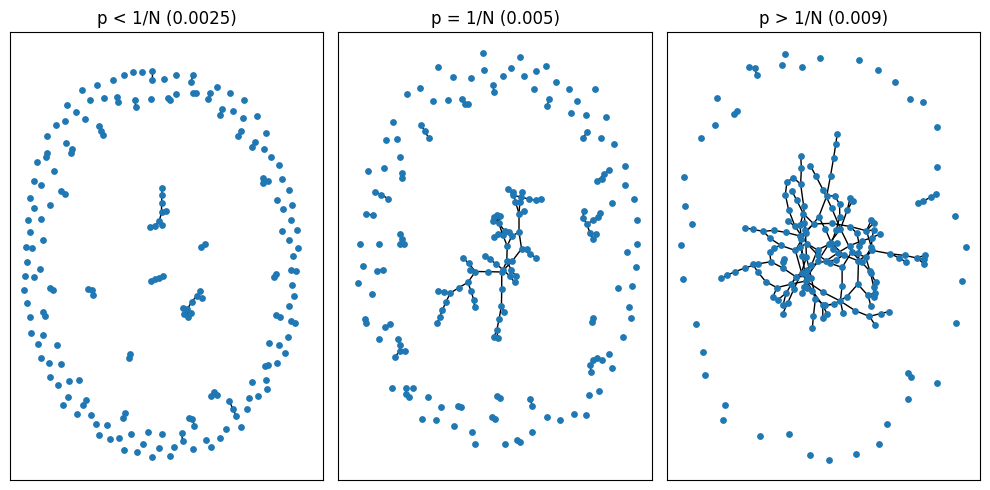

In [37]:
ANTALL = 200
SANN_1 = 0.0025 # < 1/N
SANN_2 = 0.005  # = 1/N
SANN_3 = 0.009  # > 1/N

G1 = nx.gnp_random_graph(ANTALL, SANN_1)
print(f"ANtall kanter i G1: {G1.number_of_edges()}")
G2 = nx.gnp_random_graph(ANTALL, SANN_2)
print(f"ANtall kanter i G2: {G2.number_of_edges()}")
G3 = nx.gnp_random_graph(ANTALL, SANN_3)
print(f"ANtall kanter i G3: {G3.number_of_edges()}")

# Tre sub-plot
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 5))

pos1 = nx.spring_layout(G1)
nx.draw_networkx(G1, pos1, with_labels=False, ax=ax1, node_size=15)
ax1.set_title("p < 1/N (0.0025)")

pos2 = nx.spring_layout(G2)
nx.draw_networkx(G2, pos2, with_labels= False, ax=ax2, node_size=15)
ax2.set_title("p = 1/N (0.005)")

pos3 = nx.spring_layout(G3)
nx.draw_networkx(G3, pos3, with_labels=False, ax=ax3, node_size=15)
ax3.set_title("p > 1/N (0.009)")

# Ikke overlapp, takk
plt.tight_layout()
plt.show()

Det er åpenbart stor forskjell på en sub-graf og en klikk!

Som en forberedelse til neste seksjon skal vi se på tettheten.  En grafs "størrelse" er ikke antall noder, fordi en graf med mange noder men få kanter ikke er interessant.  Det som er avgjørende er forholdet mellom antall kanter og antall noder, altså hvor "tett" grafen er.

Tallene vi bruker i eksempelet her kommer fra neste kapittel, og skal brukes til sammenligning, og de er $N=4039, p=0.01$.

Gjennomsnittlig tetthet  $\langle k \rangle$ er hvor mange kanter en tilfeldig node kan forventes å ha.  Ettersom det maksimale antall noder er ${N \choose 2} = \frac{N(N-1)}{2}$ så vil antall kanter (forventes å være) $p \frac{N(N-1)}{2} => 0.01 \frac{4039\times4038}{2} = 81547$.  Ettersom alle kanter genereres tilfeldig, og det maksimal kan være $N-1$ naboer, blir det gjennomsnittlige $p(N-1) \Rightarrow 0.01\times 4038= 40.39$.

Ettersom kantene er generert tilfeldig forvanter vi at standardavviket ikke er høyt.

Det teoretiske standardavviket er $\sigma = \sqrt{p(1-p)(N-1)} \to \sqrt{0.01 \times 0.99 \times 4038} = \sqrt{38.9861} = 6.3234.$



Teoretisk Stdev: 6.3227
Antall kanter med p=0.01 er 81494
Funnet Stdev:   6.2939


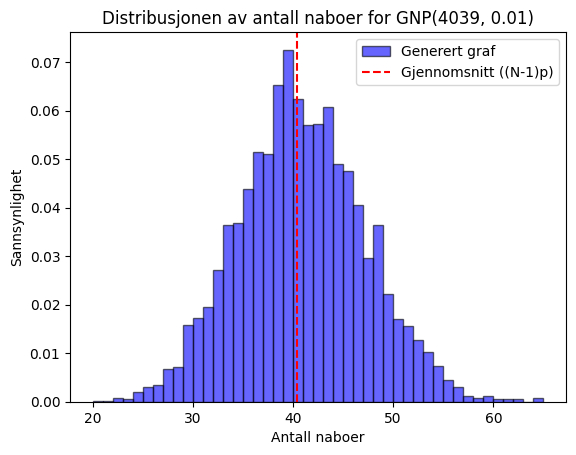

In [38]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import math

# Disse tallene tar vi med oss videre
N = 4039
p = 0.01

teoretisk_std = math.sqrt((N - 1) * p * (1 - p))
print(f"Teoretisk Stdev: {teoretisk_std:.4f}")

# Lag en graf og sjekk resultatet
G = nx.gnp_random_graph(N, p)

print(f"Antall kanter med p={p} er {G.number_of_edges()}")

# ANtall kanter i hver node
antall = []
for node, naboer in G.degree():
    antall += [naboer]
    # eller antall = [d for n, d in G.degree()]
#

# Finn stdev
funnet_std = np.std(antall)

print(f"Funnet Stdev:   {funnet_std:.4f}")

# Vis at Gauss er med
plt.hist(antall, 
         bins=range(min(antall), max(antall) + 1), 
         density=True, 
         alpha=0.6, 
         color='b', 
         edgecolor='black', 
         label='Generert graf')
plt.axvline(x=(N-1)*p, color='r', linestyle='--', label='Gjennomsnitt ((N-1)p)')
plt.xlabel('Antall naboer')
plt.ylabel('Sannsynlighet')
plt.title(f'Distribusjonen av antall naboer for GNP({N}, {p})')
plt.legend()
plt.show()

Selv om det er "lett" å bruke tilfeldige grafer som modell for verden, er det neppe en riktig mdell: Det er (mye) større sannsynlighet at jeg kjenner en av dine venner, enn at jeg kjenner en tilfeldig person et annet sted.  
Vi skal se på to datasett som illustrerer forskjellen.

# Grafer uten skala (_scale free_)



For å så en smak av hvordan virkeligheten kan se ut skal vi laste inn to datasett.  De er svært anderledes enn de tilfeldige grafene vi har sett på så langt.

## Venner på Facebook

In [39]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import gzip

G = nx.Graph()
with gzip.open("data/facebook_combined.txt.gz", "r") as fd:
    for linje in fd:
         link = linje.split()
         G.add_edge(link[0], link[1])
    #
#
print(f"Antall noder i grafen: {G.number_of_nodes()}")
print(f"Antall kanter i grafen: {G.number_of_edges()}")


Antall noder i grafen: 4039
Antall kanter i grafen: 88234


Som vi ser er antallet noder og kanter (nesten) likt med grafen vi genererte ovenfor

In [40]:

# ANtall kanter i hver node
antall = []
for node, naboer in G.degree():
    antall += [naboer]
    # eller antall = [d for n, d in G.degree()]
#
print(f"Funnet Stdev:   {np.std(antall):.4f}")
print(f"Funnet Median:   {np.mean(antall):.4f}")


Funnet Stdev:   52.4141
Funnet Median:   43.6910


I den tilfeldige grafen standardavviket 6.32 mens her er det 52.  Grafen er åpenbart grunnleggende anderledes.

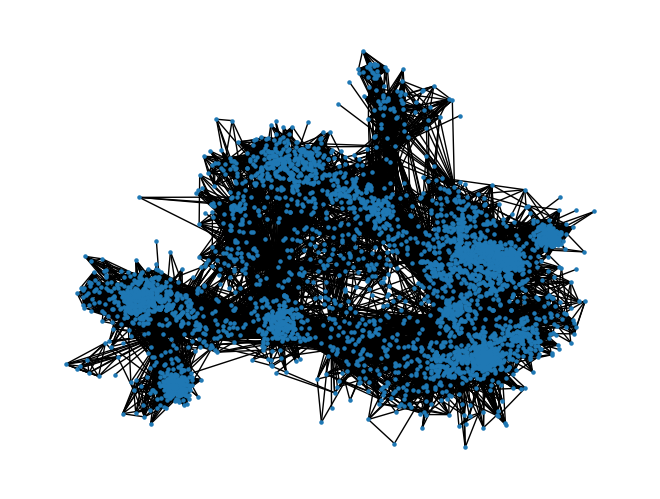

<Figure size 500x500 with 0 Axes>

In [41]:
pos = nx.spring_layout(G)  # Be nodene spre seg utover så godt de kan
nx.draw(G, with_labels=False, node_size=5)
plt.figure(figsize=(5,5))
plt.show()

Problemet er det ikke er mulig å "se" noe i dene figuren.

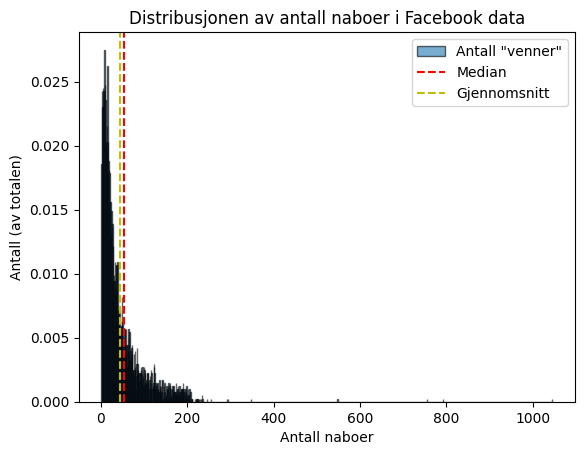

In [42]:
# Vis at Gauss absolutt ikke er med
plt.hist(antall, 
         bins=range(min(antall), max(antall) + 1), 
         density=True, 
         alpha=0.6, 
         edgecolor='black', 
         label='Antall "venner"')
plt.axvline(np.std(antall), color='r', linestyle='--', label='Median')
plt.axvline(np.mean(antall), color='y', linestyle='--', label='Gjennomsnitt')
plt.xlabel('Antall naboer')
plt.ylabel('Antall (av totalen)')
plt.title(f'Distribusjonen av antall naboer i Facebook data')
plt.legend()
plt.show()

Det er åpenbart at grafen ikke er tilfeldig; i det minste ikke i tråd med rammene for en tilfeldig graf.

## Epost fra Network Science

For bedre å forstå situasjonen skal vi se nærmere på et datasett analysert i boken [Network Science](https://networksciencebook.com), nemlig *email* settet som er ett av eksepmplene (se [figur 2.1](https://networksciencebook.com/chapter/2#table-2-1) i [kapittel 2.2](https://networksciencebook.com/chapter/2#networks-graphs)).  Basert på diskusjonen der tegner vi datasettet i $log-log$:

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import gzip

with gzip.open("data/email.edgelist.txt.gz", "rb") as fd:
    data = np.loadtxt(fd, dtype=int)
#
sender = data[:, 0]   # Første kolonne
mottaker = data[:, 1] # Andre kolonne
print(f"Antall kanter totalt: {len(sender)}")

antall_sendere, ut_kanter = np.unique(sender, return_counts=True)
print(f"Hvor mange noder (mennesker) har sendt epost: {len(antall_sendere)}")
antall_mottakere, in_kanter = np.unique(mottaker, return_counts=True)
print(f"Hvor mange noder (mennesker) har mottat epost: {len(antall_mottakere)}")


Antall kanter totalt: 103731
Hvor mange noder (mennesker) har sendt epost: 39797
Hvor mange noder (mennesker) har mottat epost: 30203


 Hvor mange noder (mennesker) har sendt epost: 39797
 Hvor mange noder (mennesker) har mottat epost: 30203


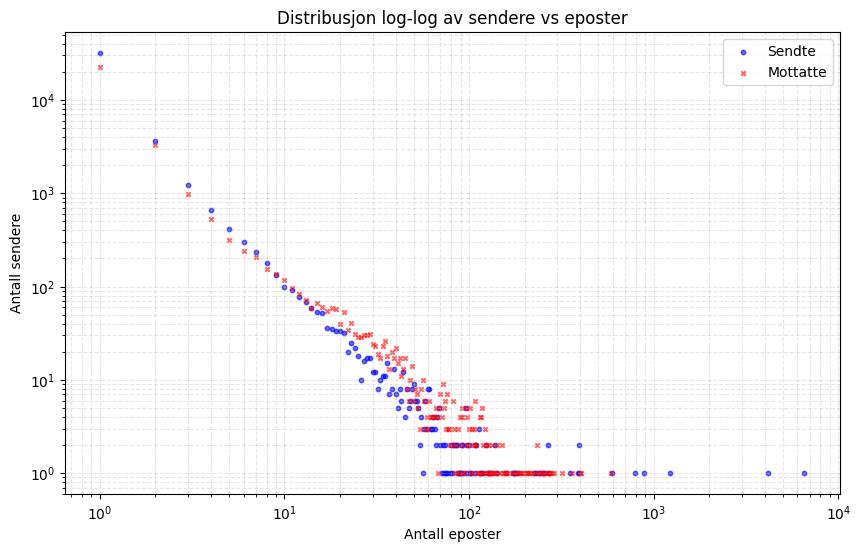

In [5]:
# tell dem opp
ut_x, ut_y = np.unique(ut_kanter, return_counts=True)
inn_x, inn_y = np.unique(in_kanter, return_counts=True)

# Tegn i log-log
plt.figure(figsize=(10, 6))
plt.scatter(ut_x, ut_y, 
            c='blue', 
            alpha=0.6, 
            label='Sendte', 
            s=10, 
            marker='o')
plt.scatter(inn_x, inn_y, 
            c='red', 
            alpha=0.6, 
            label='Mottatte', 
            s=10, 
            marker='x')
# Dette er "power-distribusjon"
plt.xscale('log')
plt.yscale('log')

plt.title("Distribusjon log-log av sendere vs eposter")
plt.xlabel("Antall eposter")
plt.ylabel("Antall sendere")
plt.legend()
plt.grid(True, which="both", linestyle='--', alpha=0.3)

plt.show()



Et blikk forteller oss at $\gt 10^4$ noder (mennesker) har sendt eller mottatt bare én epost, mens én ser ut til å ha sendt nesten $10^4$ eposter.  Forskjellen er dramatisk, for å si det forsiktig.

La oss forsøke å tegne

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import gzip

G = nx.DiGraph()
# husk at gzip påpner i 'b'
with gzip.open("data/email.edgelist.txt.gz", "rt") as fd:
    for linje in fd:
         link = linje.split()
         G.add_edge(int(link[0]), int(link[1]))
    #
#
print(f"Antall noder i grafen: {G.number_of_nodes()}")
print(f"Antall kanter i grafen: {G.number_of_edges()} (antall eposter)")
# Bort med eposter sendt til seg selv
G.remove_edges_from(nx.selfloop_edges(G))
print(f"Antall kanter etter selv-loop: {G.number_of_edges()}")
# Og noder uten linker til seg nå
isolerte = list(nx.isolates(G)) # kan ikke bruke iteratorer direkte
G.remove_nodes_from(isolerte)
print(f"Antall noder etter isolerte: {G.number_of_nodes()}")
# ANtall kanter i hver node
antall = []
for node, naboer in G.degree():
    antall += [naboer]
    # eller antall = [d for n, d in G.degree()]
#
print(f"Funnet Stdev:   {np.std(antall):.4f}")
print(f"Funnet Median:   {np.mean(antall):.4f}")

Antall noder i grafen: 57194
Antall kanter i grafen: 103731 (antall eposter)
Antall kanter etter selv-loop: 103083
Antall noder etter isolerte: 57189
Funnet Stdev:   36.0183
Funnet Median:   3.6050


Gauss er ikke med her heller.

La oss velge noen  noder tilfeldig og se:

In [3]:
import random

for i in range(10):
    node = int(random.random() * G.number_of_nodes())
    print(f"Node {node}: {len(G.in_edges(node))} {len(G.out_edges(node))}")

Node 36952: 1 0
Node 31364: 0 1
Node 34429: 1 1
Node 35082: 0 1
Node 2024: 13 0
Node 41999: 0 1
Node 18282: 2 3
Node 38271: 1 1
Node 10606: 1 1
Node 51094: 0 1


Men la oss se på noen utvalgte noder:

In [4]:
print(f"63    ut: {len(G.out_edges(63))}  in: {len(G.in_edges(63))}")
print(f"40    ut: {len(G.out_edges(40))}   in: {len(G.in_edges(40))}")
print(f"407   ut: {len(G.out_edges(407))}   in: {len(G.in_edges(407))}")
print(f"1704  ut: {len(G.out_edges(1704))}  in: {len(G.in_edges(1704))}")
print(f"11798 ut: {len(G.out_edges(11798))} in: {len(G.in_edges(11798))}")
print(f"11028 ut: {len(G.out_edges(11028))} in: {len(G.in_edges(11028))}")
print(f"32199 ut: {len(G.out_edges(32199))} in: {len(G.in_edges(32199))}")

63    ut: 13  in: 29
40    ut: 0   in: 274
407   ut: 0   in: 205
1704  ut: 51  in: 107
11798 ut: 881 in: 262
11028 ut: 4170 in: 8
32199 ut: 6553 in: 2


Det er ingen tvil: Dette er ikke normalfordelt!

### Visualisering av en graf uten skala

Problemet er at en generell visualisering er *svært* vanskelig å få til.  De kule vi har sett av Internett er håndlagede!
Dette er det beste jeg har fått til

In [11]:
from ipysigma import Sigma
import math

log_degree = {}
for node, deg in G.degree():
    log_degree[node] = math.log(deg + 1) 
#    
Sigma(
    G, 
    node_size=log_degree,
    node_color=log_degree,
    node_color_gradient="Plasma",
    node_size_range=(1, 30),
    default_edge_type="curve"
)

Sigma(nx.DiGraph with 57,189 nodes and 103,083 edges)

### Lete etter strukturer

#### Klikker
Definisjonen av en *klikk* er ikke gyldig for en rettet graf (slik epost er).  Men om A sender epost til B (rettet) har jo B åpenbart en relasjon til A.  For å lete etter klikker konverterer vi grafen til urettet graf, og leter der.

Å konvertere en rettet graf til en uten retning virker som en rimelig ting for å se på strukturer.

In [6]:
import networkx as nx
#Finn den største klikken i grafen
UG = G.to_undirected(G)
klikker = list(nx.find_cliques(UG))
# Finn den lengste listen i listen av noder
klikk = max(klikker, key=len)

# Hvem er med
print("Største klikk:", klikk)
for i in klikk:
    print(f"Node {i}: {len(G.in_edges(i))} {len(G.out_edges(i))}")

Største klikk: [732, 13448, 1632, 953, 1730, 18627]
Node 732: 91 0
Node 13448: 4 126
Node 1632: 136 100
Node 953: 68 40
Node 1730: 29 14
Node 18627: 3 4


In [8]:
# Beregne de tre viktigste typene sentralitet
import time

populæritet = nx.degree_centrality(UG)
top_populære_noder = sorted(populæritet, key=populæritet.get, reverse=True)[:5]
print("5 mest populære:")
for n in top_populære_noder:
    print(f"\t Node: {n} Naboer: {UG.degree[n]}")
#

start = time.time()
sentrale = nx.closeness_centrality(UG)
top_sentrale = sorted(sentrale, key=sentrale.get, reverse=True)[:5]
print("5 mest sentrale noder:")
for n in top_sentrale:
    print(f"\t Node: {n} Naboer: {UG.degree[n]}")
#   
print(f"Å finne sentrale noder {time.time()-start:.2f} sekunder")

start = time.time()
broer = nx.betweenness_centrality(UG)
top_bronoder = sorted(broer, key=broer.get, reverse=True)[:5]
print("5 viktigste bronoder")
for n in top_bronoder:
    print(f"\t Node: {n} Naboer: {UG.degree[n]}")
#
print(f"Å finne sentrale noder {time.time()-start:.2f} sekunder")




5 mest populære:
	 Node: 32199 Naboer: 6553
	 Node: 11028 Naboer: 4171
	 Node: 13678 Naboer: 1228
	 Node: 11798 Naboer: 1018
	 Node: 13498 Naboer: 802
5 mest sentrale noder:
	 Node: 11028 Naboer: 4171
	 Node: 32199 Naboer: 6553
	 Node: 11798 Naboer: 1018
	 Node: 13498 Naboer: 802
	 Node: 12586 Naboer: 289
Å finne sentrale noder 1245.31 sekunder


KeyboardInterrupt: 

Her er svaret slik det ble regnet ut forrige gang:
5 mest populære:
- 32199 {}
- 11028 {}
- 13678 {}
- 11798 {}
- 13498 {}

5 mest sentrale noder:
- 11798 {}
- 12586 {}
- 180 {}
- 196 {}
- 1763 {}

Å finne sentrale noder 262.94 sekunder

5 viktigste bronoder
- 11798 {}
- 1189 {}
- 32199 {}
- 11028 {}
- 13498 {}

Å finne sentrale noder 3063.63 sekunder

La oss så se hvilke noder som er "viktigst" i betydningen "eigenvector"

In [10]:
# Beregne de viktigste nodene
page_rank = nx.eigenvector_centrality(G)

viktigste_noder = sorted(page_rank, key=page_rank.get, reverse=True)[:5]

print("5 mest populære:")
for n in viktigste_noder:
    print(f"\t Node {n}  har {G.degree[n]} naboer")
#   


5 mest populære:
	 Node 11798  har 1143 naboer
	 Node 12586  har 333 naboer
	 Node 14603  har 297 naboer
	 Node 288  har 108 naboer
	 Node 33  har 112 naboer


Legg merke til at ingen av q12586, 14603, 288, eller 33 er på lisyene over